# Phase 3: Feature Extraction

## Where this phase fits in the project

Studios decide which scripts to greenlight under sharp cost
asymmetry: producing a flop costs roughly fifty million
dollars in lost budget, while passing on a hit can cost two
to four times that in foregone revenue. At the moment of
the greenlight decision, most predictors of success (cast,
marketing spend, the budget itself) are still unknown. The
only signal that exists is the script.

This project trains a triage model that reads a screenplay's
dialogue and outputs a recommendation (greenlight, pass, or
refer to a human reader) together with a calibrated
confidence interval and an explanation of which scenes
drove the recommendation. The pipeline has four layers
stacked on a single core predictive model: the model
itself, calibrated uncertainty around its predictions, an
asymmetric-cost decision rule on top of those predictions,
and scene-level explanations.

Phase 1 verified that we have enough usable data, and
Phase 2 produced a clean processed corpus of 1,713 films
with screenplays, IMDb ratings, budgets, and revenues. This
notebook documents Phase 3, which converts each screenplay
into a fixed-length feature vector that the modelling phase
will consume.

## How Phase 3 is organized

Feature engineering carries methodological risk. Adding many
features at once makes it impossible to tell which ones
actually help and which ones are noise. To avoid that, we
split Phase 3 into two parts.

**Part A (this notebook).** Establish a performance floor
using only features that already exist on the processed
corpus, with a deliberately simple linear model. The floor
answers a basic question: how well can we predict film
success from screenplay structure alone, before any text
engineering? Without that number, we have nothing to
measure subsequent feature engineering against.

**Part B (added later).** Add five engineered feature
groups one at a time (lexical, sentiment, topic, embedding,
character network), retraining the same baseline after each
group and recording the lift each contributes. Each group
is preceded by a written prediction of expected lift, then
compared against the actual lift. This produces a clean
ablation table for the report and prevents the team from
retrofitting explanations to whatever happened to work.

Part A is what this notebook documents. Part B sections will
be appended once each feature group is implemented.

## What we predict

Three prediction targets are tracked in parallel. The choice
of which one to feature in the final report is deferred
until after the modelling phase, when comparative results
are available.

* `log_roi`, the natural log of return-on-investment,
  defined as `ln(revenue) - ln(budget)`. A regression
  target.
* `roi_gt_1`, a boolean indicator for revenue greater than
  budget (gross profitability). A classification target.
* `roi_gt_2`, a boolean indicator for revenue greater than
  twice budget. The doubling threshold is the industry
  rule of thumb for net profitability after marketing and
  distribution overhead. A classification target.

The three are constructed so they share threshold
consistency: `roi_gt_1` is the same as `log_roi > 0`, and
`roi_gt_2` is the same as `log_roi > ln 2`. A single
regression on `log_roi` therefore reproduces both
classifiers by thresholding, which makes downstream
comparisons clean.

## 0. Environment setup

The first cell finds the project root, adds it to
`sys.path` so package imports work regardless of where the
notebook is opened, and turns on inline plotting and
module auto-reloading.

In [18]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the directory tree until docs/PROJECT_CONTEXT is found."""
    markers = ("docs/PROJECT_CONTEXT.md", "docs/PROJECT_CONTEXT.txt")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")
get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Common imports for the rest of the notebook.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import paths

paths.ensure_dirs()
print("Processed data:  ", paths.DATA_PROCESSED_DIR)
print("Reports figures: ", paths.REPORTS_FIGURES_DIR)
print("Reports tables:  ", paths.REPORTS_TABLES_DIR)

Processed data:   /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/data/processed
Reports figures:  /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/reports/figures
Reports tables:   /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/reports/tables


---

## 1. Defining the three prediction targets

Before we can split the data or train any model, we need
to be precise about what we are predicting. This section
constructs the three target columns and inspects their
distributions.

### Why log of ROI for the regression target

Return-on-investment in raw form is heavily right-skewed.
On this corpus the median is around 2.9, but the maximum
approaches 8500, and the distribution has a thick upper
tail that pulls the mean far above the median. Standard
regression models trained against squared-error loss are
dominated by such tails, fitting the few extreme values at
the expense of the bulk of the data. Taking the logarithm
compresses the tail and produces a distribution that is
approximately symmetric around its median, which satisfies
the standard regression assumptions far better.

Two further reasons motivate the log form specifically.
First, it decomposes cleanly: `log(revenue/budget)` equals
`log(revenue) - log(budget)`, both of which are already
stored on the processed corpus. The modelling phase can
therefore choose to model the joint quantity directly or to
model the two components separately. Second, the
log-transformed target has direct correspondence with the
two classification thresholds (zero and `ln 2`), so a
single regression model produces both classifiers by
thresholding.

### Why two classification thresholds rather than one

The naive choice of "profitable versus not profitable" uses
the threshold revenue equals budget, which corresponds to a
gross-profitable cutoff. On this corpus that threshold is
positive for roughly 80 percent of films. A target with
such a skewed positive class is easy to game with a "always
predict positive" model and gives little headroom for
features to demonstrate predictive lift.

The doubling threshold (revenue greater than twice budget)
captures the industry's rule of thumb for net profitability
after marketing and distribution overhead. On this corpus
it produces a more balanced 64 percent positive rate, which
gives more discriminating power to the AUC and PR metrics.
Tracking both thresholds in parallel lets us compare which
notion of success the screenplay carries information about.

In [20]:
from src.features.targets import (
    ALL_TARGETS, LOG_ROI_COL, ROI_GT_1_COL, ROI_GT_2_COL,
    add_targets,
)

df = pd.read_parquet(paths.DATA_PROCESSED_DIR / "films_joined.parquet")
df_with_targets = add_targets(df)
print(f"Corpus: {len(df_with_targets):,} films")
for col in ALL_TARGETS:
    print(f"  {col:<12}  dtype: {str(df_with_targets[col].dtype):<8}")

Corpus: 1,713 films
  log_roi       dtype: float64 
  roi_gt_1      dtype: bool    
  roi_gt_2      dtype: bool    


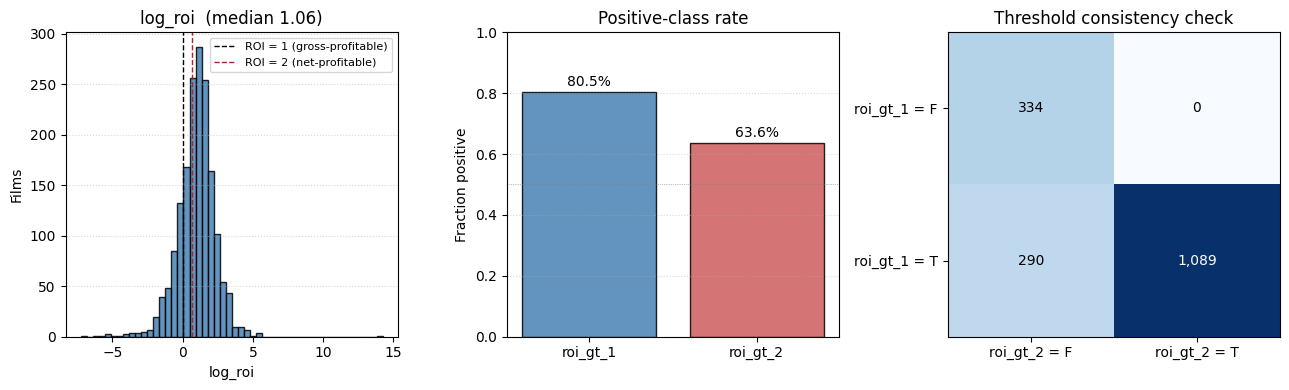

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

log_roi = df_with_targets[LOG_ROI_COL]
axes[0].hist(log_roi, bins=50, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="ROI = 1 (gross-profitable)")
axes[0].axvline(np.log(2), color="firebrick", linewidth=1, linestyle="--", label="ROI = 2 (net-profitable)")
axes[0].set(title=f"log_roi  (median {log_roi.median():.2f})", xlabel="log_roi", ylabel="Films")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

rates = {
    "roi_gt_1": df_with_targets[ROI_GT_1_COL].mean(),
    "roi_gt_2": df_with_targets[ROI_GT_2_COL].mean(),
}
bars = axes[1].bar(list(rates.keys()), list(rates.values()),
                   color=["steelblue", "indianred"], edgecolor="black", alpha=0.85)
axes[1].set(title="Positive-class rate", ylabel="Fraction positive", ylim=(0, 1))
for bar, rate in zip(bars, rates.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, rate + 0.02,
                 f"{rate:.1%}", ha="center", fontsize=10)
axes[1].axhline(0.5, color="gray", linewidth=0.5, linestyle=":")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

cross = pd.crosstab(df_with_targets[ROI_GT_1_COL], df_with_targets[ROI_GT_2_COL])
cross = cross.reindex(index=[False, True], columns=[False, True], fill_value=0)
axes[2].imshow(cross.values, cmap="Blues", aspect="auto")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["roi_gt_2 = F", "roi_gt_2 = T"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["roi_gt_1 = F", "roi_gt_1 = T"])
axes[2].set(title="Threshold consistency check")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cross.values[i, j]:,}", ha="center", va="center",
                     color="white" if cross.values[i, j] > cross.values.max() / 2 else "black")

fig.tight_layout()
fig.savefig(paths.REPORTS_FIGURES_DIR / "phase3_target_distributions.png", dpi=120)
plt.show()

The left panel shows the regression target. Its symmetry
around the median value of roughly 1.06 (corresponding to a
revenue of about 2.9 times budget) confirms that the log
transform produced a distribution suitable for linear
regression. The two dashed lines mark the locations of the
classification thresholds.

The middle panel shows the positive-class rates for the two
classification targets. The 80 percent positive rate on
`roi_gt_1` reflects survivorship in the corpus: every film
in the dataset was both produced and recognized enough to
appear on a major metadata aggregator, which selects for
success. We discuss the implications for the cost-decision
layer of the system in a later phase. The 64 percent
positive rate on `roi_gt_2` is closer to balanced and gives
the model more room to discriminate.

The right panel verifies the threshold-consistency
construction. Every film with `roi_gt_2 = True` also has
`roi_gt_1 = True` (the upper-right cell is empty as
expected), and the proportions across cells match the
cumulative ROI distribution.

---

## 2. Splitting the corpus

We need to evaluate predictive performance honestly, which
means setting aside data the model never sees during
training. Two considerations shape the split design.

### Why three-way rather than two-way

A standard train and test split would suffice for the core
predictive model. The downstream calibration layer of the
triage system, however, requires a separate pool of data
the model has not seen, used to fit conformal-prediction
intervals. Carving that calibration set out now, before any
feature fitting touches the data distribution, ensures we
do not have to redo the split later and avoids leakage
across the calibration step.

We use a 70 / 15 / 15 split: about 1,200 films for training,
257 for calibration, and 257 for held-out testing. The 15
percent calibration set is large enough to produce stable
conformal intervals, and the same size for the test set
gives sufficient power to detect meaningful differences
between candidate models in the final evaluation.

### Why stratified

Two properties of the corpus would create a noisy split if
we sampled at random. First, the genre distribution has a
long tail: Drama, Comedy, Action, and Thriller dominate
while smaller genres each contain only a few dozen films.
A random split could end up with all the Animation films
in the test set and none in the training set. Second, the
corpus spans nine decades with very uneven density: the
2000s and 2010s contain hundreds of films while the
pre-1980s decades each contain fewer than thirty. Both
factors plausibly affect the relationship between
screenplay features and outcomes, so we want to balance
them across splits.

We therefore stratify by the cross of primary genre and a
coarse decade bucket. Pre-1980 decades are pooled into a
single bucket because each is too thin on its own. The
2010s and 2020s are pooled because the 2020s coverage in
the corpus extends only to 2023.

### Handling rare cells

The cross of genre and decade bucket produces some cells
that are too small for stratification to function (for
example, fewer than five Animation films in the
pre-1980s). We pool any cell with fewer than five films
into a single rare bucket so that the stratifier sees a
well-defined population for every named cell. Roughly
thirty-eight films land in that pool, around two percent of
the corpus.

The split is implemented in `src/features/split.py`. All
knobs (target proportions, decade boundaries, rare-cell
threshold, random seed) live on a configuration dataclass
so alternative split designs can be tried without changing
any code.

In [22]:
from src.features.split import (
    SplitConfig, make_splits, split_diagnostics,
)

config = SplitConfig()
print("Split configuration:")
print(f"  train / calibration / test:  {config.train_frac} / "
      f"{config.cal_frac} / {config.test_frac}")
print(f"  rare-cell threshold:         {config.rare_cell_threshold}")
print(f"  random seed:                 {config.seed}")

Split configuration:
  train / calibration / test:  0.7 / 0.15 / 0.15
  rare-cell threshold:         5
  random seed:                 42


In [23]:
splits = make_splits(df, config)
counts = splits["split"].value_counts().reindex(["train", "cal", "test"])

print("Resulting split sizes:")
for name, n in counts.items():
    label = {"train": "Train", "cal": "Calibration", "test": "Test"}[name]
    print(f"  {label:<13} {n:>5,}   ({100 * n / len(df):.1f}% of corpus)")

Resulting split sizes:
  Train         1,199   (70.0% of corpus)
  Calibration     257   (15.0% of corpus)
  Test            257   (15.0% of corpus)


We verified reproducibility by running the split twice with
the default configuration; the assignments are
byte-identical across runs. The result is saved to
`data/processed/split_assignments.parquet` so every
downstream step uses the same definitive partition.

### Stratum diagnostics

In [24]:
diagnostics = split_diagnostics(splits)
print(f"Number of strata used: {len(diagnostics)}")
rare_count = int(diagnostics.loc[diagnostics['stratum'] == 'rare|rare', 'total'].sum())
print(f"Films pooled into the rare bucket: {rare_count}")
print()
print("Top 10 strata by size:")
diagnostics.head(10)

Number of strata used: 57
Films pooled into the rare bucket: 38

Top 10 strata by size:


split,stratum,train,cal,test,total
0,Drama|2010s_2020s,141,30,30,201
1,Comedy|2010s_2020s,79,17,17,113
2,Drama|2000s,67,15,15,97
3,Action|2010s_2020s,61,13,13,87
4,Drama|1990s,54,12,12,78
5,Comedy|2000s,53,12,11,76
6,Action|2000s,48,10,10,68
7,Comedy|1990s,47,10,10,67
8,Action|1990s,44,9,10,63
9,Horror|2010s_2020s,30,7,7,44


The full diagnostic table is saved to
`reports/tables/phase3_split_diagnostics.csv`. Every named
stratum (genre, decade pair) has at least one film in each
of the three splits, confirming that the stratifier
functions as intended. The rare bucket absorbs the long
tail of small cells without collapsing the rest of the
corpus into less granular strata.

---

## 3. Choosing features for the baseline

The point of the baseline is to establish how well a
simple model performs without any text-derived feature
engineering. We need to select features that meet two
criteria: they should already exist on the processed
corpus (or be trivially derivable), and they should be
available at the moment the system would actually be used.
The second criterion is important: the system is meant to
run before the studio greenlights the film, so any feature
that depends on the studio's eventual decisions (budget,
marketing, cast) is not available at the moment of
prediction.

### Features used in the deployable baseline

**Screenplay-structural features.** Phase 2's parser
extracted seven aggregate measures of each screenplay's
structure from its XML form: number of scenes, number of
unique characters, number of dialogue lines, total
character counts for dialogue and for action description,
the dialogue-to-total-text ratio, and a count of structural
irregularities encountered while parsing. These are all
properties of the screenplay itself, available at
pre-greenlight time.

**Release year.** Year of release encoded as a numeric
feature. We expect it to carry a small amount of signal
about era-specific market dynamics. Although the actual
release year is not known until the film is released, the
year of submission is a reasonable proxy and is always
available.

**Primary genre, one-hot encoded.** Genre is an obvious
confound and a strong correlate of both budget and
revenue. Phase 2 grouped genres with fewer than thirty
films into an "Other" category to keep cell sizes
well-conditioned, leaving thirteen genre dummies.

**Runtime.** A film's intended runtime in minutes. The
screenplay's page count is a tight proxy for runtime
(industry convention is roughly one page per minute), so
runtime is leak-free at the pre-greenlight moment even
though the final theatrical runtime might differ
slightly. We use the log-transformed form for consistency
with the other heavy-tailed counts.

### A separate ceiling baseline includes budget

Budget is the central decision the system is meant to
inform, and is not available at inference time. We
therefore exclude it from the deployable baseline. It is
useful, however, to train a parallel model that includes
log-budget, purely as a diagnostic. If budget alone
produced a strong baseline, it would mean the deployable
model is competing against a dominant signal it cannot
access. If budget contributes little, it suggests the
deployable features have meaningful headroom. We discuss
what we found below.

---

## 4. Why we apply a log transform to several features

Several of the structural counts above are heavily
right-skewed. A film with an unusually large cast or an
unusually long screenplay sits multiple standard
deviations above the median, while most films sit close to
the median. When a linear regression is fit on z-scored
raw values of such a column, the heavy-tail observations
dominate the gradient and the model effectively learns to
fit them well while ignoring the bulk of the data.

The standard fix is to compress the tail with a logarithm
before standardization. We use the form `log(1 + x)`
rather than `log(x)` because one of the features
(`parse_warning_count`) takes the value zero on the
majority of films, and the bare log would propagate
negative infinity. The `log(1 + x)` form is well-defined
at zero and is approximately equal to `log(x)` for the
non-zero values where the compression is needed.

The log transform is applied to six of the seven
structural counts: `n_scenes`, `n_unique_characters`,
`n_dialogue_lines`, `total_dialogue_chars`,
`total_action_chars`, and `parse_warning_count`. The
seventh, `dialogue_to_total_text_ratio`, is already a
bounded proportion in the interval zero to one and does
not benefit from log transformation.

The figure below shows the effect of the transform on
three representative columns.

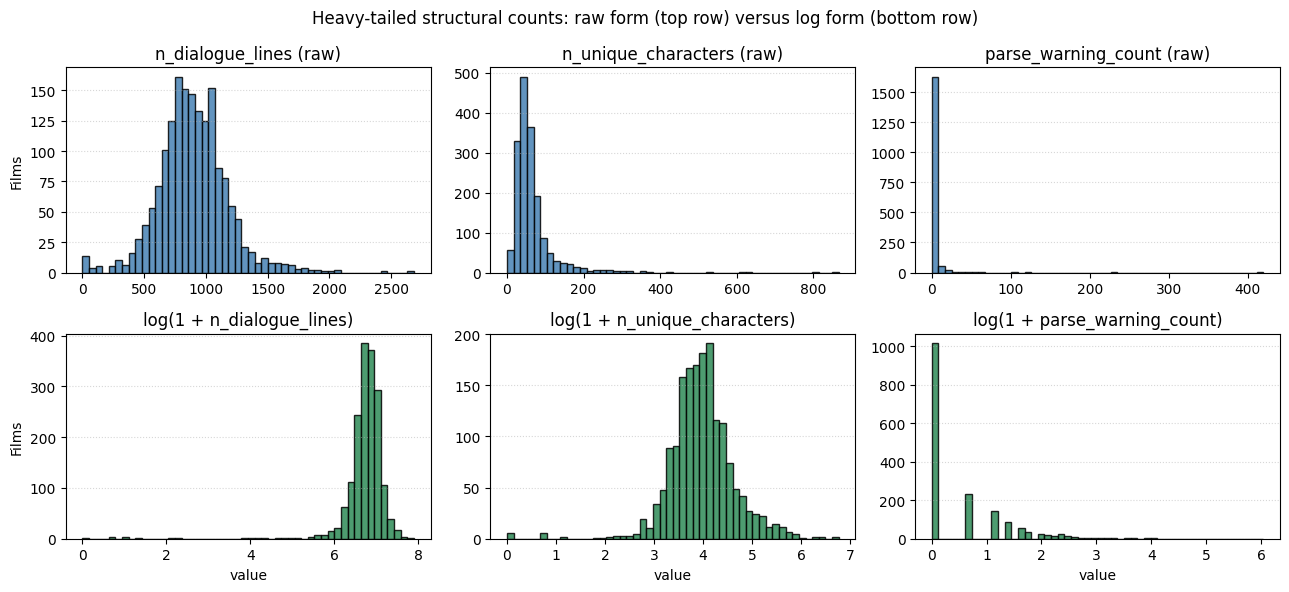

In [25]:
from src.features.baseline_features import LOG_TRANSFORMABLE

cols_to_show = ["n_dialogue_lines", "n_unique_characters", "parse_warning_count"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, col in enumerate(cols_to_show):
    raw = df_with_targets[col].astype(float)
    logged = np.log1p(raw)
    axes[0, j].hist(raw, bins=50, color="steelblue", edgecolor="black", alpha=0.85)
    axes[0, j].set(title=f"{col} (raw)", ylabel="Films" if j == 0 else "")
    axes[0, j].grid(axis="y", linestyle=":", alpha=0.5)
    axes[1, j].hist(logged, bins=50, color="seagreen", edgecolor="black", alpha=0.85)
    axes[1, j].set(title=f"log(1 + {col})",
                   ylabel="Films" if j == 0 else "", xlabel="value")
    axes[1, j].grid(axis="y", linestyle=":", alpha=0.5)
fig.suptitle("Heavy-tailed structural counts: raw form (top row) versus log form (bottom row)")
fig.tight_layout()
fig.savefig(paths.REPORTS_FIGURES_DIR / "phase3_log_transform_effect.png", dpi=120)
plt.show()

The raw distributions exhibit pronounced right skew with
thin tails reaching far above the bulk. The log-transformed
versions are closer to symmetric and unimodal, which is
the shape a linear model with z-score standardization is
designed to handle. The transform is most consequential
for `parse_warning_count`, where the raw distribution is
dominated by a heavy spike at zero with a thin tail of
warning-heavy films, and the log form spreads the non-zero
observations across a more interpretable range.

### Building the feature matrix

In [26]:
from src.features.baseline_features import (
    BaselineFeatureConfig, build_baseline_features,
)

feature_cfg = BaselineFeatureConfig(
    include_log_budget=False,
    log_transform_structural=True,
    include_log_runtime=True,
)
X_dialogue_only = build_baseline_features(df_with_targets, feature_cfg)
print(f"Feature matrix shape: {X_dialogue_only.shape}")
print(f"First five columns: {list(X_dialogue_only.columns[:5])}")
print(f"Last three columns: {list(X_dialogue_only.columns[-3:])}")

Feature matrix shape: (1713, 26)
First five columns: ['log_n_scenes', 'log_n_unique_characters', 'log_n_dialogue_lines', 'log_total_dialogue_chars', 'log_total_action_chars']
Last three columns: ['genre_Thriller', 'genre_War', 'log_runtime']


---

## 5. Model choice, cross-validation, and confidence intervals

### Model families

For the regression target we use ridge regression with
cross-validated regularization strength. Ridge is the
standard linear baseline and is robust to the modest
multicollinearity that the genre dummies introduce. The
regularization strength is selected by leave-one-out
generalized cross-validation, which has the practical
advantage of being parameter-free at the level of fold
count and is fast to compute.

For the two classification targets we use logistic
regression with an L2 penalty and cross-validated
regularization strength. Same regularization family as the
regression model, which keeps the comparison across the
three targets clean. The regularization strength is
selected via inner five-fold stratified cross-validation
optimizing AUC.

Both models are wrapped in a pipeline that applies
z-score standardization to the numeric columns and passes
the genre dummies through unchanged. Standardization
happens inside each cross-validation fold so that the
scaling parameters are estimated only on training data and
applied to the held-out fold, avoiding leakage.

### Cross-validation

We use five-fold cross-validation over the training split
only. The calibration set and test set are not touched at
this stage. For the regression target we use plain
five-fold; for the classification targets we use stratified
five-fold so each fold reflects the global positive-class
rate, which matters in particular for `roi_gt_1` where the
positive class dominates.

Within each cross-validation iteration we record the
out-of-fold predictions. Concatenating these across the
five folds gives one prediction per training-set film,
which is what we evaluate the metrics on.

### Bootstrap confidence intervals

Each headline metric is reported with a 95-percent
confidence interval computed by percentile bootstrap (1,000
resamples, seed fixed for reproducibility). This gives a
sense of how much the metric estimate would vary under
re-sampling, which matters because the corpus is not large.
For AUC, bootstrap samples that happen to contain only a
single class are skipped rather than producing missing
values, which is standard practice.

We also choose to report several metrics per target rather
than a single headline number: R-squared, mean absolute
error, and root-mean-square error for the regression;
AUC-ROC and PR-AUC for each classifier. Each metric
captures a different aspect of model quality, and reporting
more than one helps the reader see when a single number
would be misleading.

### Running the baseline

We train two configurations of the baseline. The first
uses the dialogue-only features described in Section 3 and
is the deployable model: it represents how well the system
could perform at the pre-greenlight moment using only
information available from the screenplay and basic
metadata. The second adds the log of budget as a sanity
check, to show how much budget knowledge alone would buy.

In [27]:
from src.models.baseline.train import (
    BaselineTrainConfig, evaluate_feature_set,
)

train_cfg = BaselineTrainConfig()
train_ids = splits.loc[splits["split"] == "train", "imdb_id"]
df_train = (
    df_with_targets[df_with_targets["imdb_id"].isin(train_ids)]
    .reset_index(drop=True)
)
print(f"Training set: {len(df_train):,} films")

Training set: 1,199 films


In [28]:
rows: list[dict] = []
configurations = [
    ("Dialogue only", BaselineFeatureConfig(
        include_log_budget=False,
        log_transform_structural=True,
        include_log_runtime=True,
    )),
    ("Dialogue + log_budget", BaselineFeatureConfig(
        include_log_budget=True,
        log_transform_structural=True,
        include_log_runtime=True,
    )),
]
for name, fc in configurations:
    print(f"Training: {name}")
    label = "dialogue_only_logged" if not fc.include_log_budget else "with_budget_logged"
    rows.extend(evaluate_feature_set(df_train, fc, train_cfg, set_name=label))
baseline = pd.DataFrame(rows)
print(f"\nBaseline rows produced: {len(baseline)}")

Training: Dialogue only
2026-05-03 14:55:32 | INFO    | src.models.baseline.train | dialogue_only_logged | log_roi | r2 = 0.0524 [CI 0.0258, 0.0804]
2026-05-03 14:55:32 | INFO    | src.models.baseline.train | dialogue_only_logged | log_roi | mae = 0.9484 [CI 0.8955, 1.0025]
2026-05-03 14:55:32 | INFO    | src.models.baseline.train | dialogue_only_logged | log_roi | rmse = 1.3385 [CI 1.2193, 1.4713]
2026-05-03 14:55:33 | INFO    | src.models.baseline.train | dialogue_only_logged | roi_gt_1 | auc_roc = 0.5581 [CI 0.5194, 0.5989]
2026-05-03 14:55:33 | INFO    | src.models.baseline.train | dialogue_only_logged | roi_gt_1 | pr_auc = 0.8463 [CI 0.8212, 0.8740]
2026-05-03 14:55:35 | INFO    | src.models.baseline.train | dialogue_only_logged | roi_gt_2 | auc_roc = 0.6017 [CI 0.5724, 0.6358]
2026-05-03 14:55:35 | INFO    | src.models.baseline.train | dialogue_only_logged | roi_gt_2 | pr_auc = 0.7386 [CI 0.7087, 0.7735]
Training: Dialogue + log_budget
2026-05-03 14:55:35 | INFO    | src.models.b

---

## 6. Results

### 6.1 Deployable baseline (dialogue features only)

In [29]:
deployable = (
    baseline[baseline["feature_set"] == "dialogue_only_logged"]
    .pivot_table(index="target", columns="metric", values="value")
    .round(3)
)
deployable

metric,auc_roc,mae,pr_auc,r2,rmse
target,,,,,
log_roi,NaN,0.948,NaN,0.052,1.338
roi_gt_1,0.558,NaN,0.846,NaN,NaN
roi_gt_2,0.602,NaN,0.739,NaN,NaN


Reading the table:

* On the regression target, R-squared is roughly 0.05.
  Mean absolute error in log units is about 0.95, which
  translates to a typical prediction error of roughly 2.6x
  on raw ROI. RMSE is somewhat higher because the squared
  loss penalizes the heavy-tail observations more.
* On the easier classification target (`roi_gt_2`), AUC is
  approximately 0.60. This means that for a randomly
  chosen pair of films, one of which doubled its budget and
  one of which did not, the model ranks them in the
  correct order roughly six times in ten.
* On the harder classification target (`roi_gt_1`), AUC is
  approximately 0.56. The PR-AUC of about 0.85 looks
  impressive but is misleading on its own: with 80 percent
  of films already in the positive class, the random-guess
  PR-AUC is around 0.80, so the model's lift over random
  is only about five PR-AUC points.

These numbers represent what a simple linear model can
learn from screenplay structure alone, with no
text-derived feature engineering. They are modest. They
are also non-trivial: the model is meaningfully above
chance on both classification targets and explains a
small but real share of variance on the regression target.
Published work on similar screenplay-prediction tasks (for
example using sentence embeddings to predict Oscar
nominations or rating-based outcomes) reports floor
baselines in roughly this same band, before introducing
the more sophisticated text features.

### 6.2 The with-budget sanity check

In [30]:
ceiling = (
    baseline[baseline["feature_set"] == "with_budget_logged"]
    .pivot_table(index="target", columns="metric", values="value")
    .round(3)
)
ceiling

metric,auc_roc,mae,pr_auc,r2,rmse
target,,,,,
log_roi,NaN,0.947,NaN,0.099,1.305
roi_gt_1,0.555,NaN,0.845,NaN,NaN
roi_gt_2,0.603,NaN,0.738,NaN,NaN


Adding the log of budget to the same model lifts the
regression R-squared from about 0.05 to about 0.10. That
sounds like a sizeable relative gain, and it is, but the
absolute number is still small. AUC on the classification
targets barely moves, and on `roi_gt_1` it actually edges
down slightly within the noise.

We interpret this finding two ways. First, it confirms the
survivorship structure of the corpus. Every film in the
dataset was both produced and recognized enough to appear
on a major metadata aggregator, which selects strongly for
success. Within that already-selected population, budget
does not separate hits from misses with much precision.
Second, and more importantly for our purposes, it means
the deployable model is not competing against a dominant
budget signal it cannot access. Whatever lift the
engineered features in Part B contribute will be genuinely
incremental information from the screenplay text, not a
weak proxy for budget.

---

## 7. Did the baseline pass the threshold for proceeding?

Before starting feature engineering, we set a minimum
performance threshold the baseline had to meet to justify
the investment. The reasoning is straightforward: if a
simple linear model on screenplay structure cannot beat
chance by any meaningful margin, then the dialogue-only
framing of the project is in trouble and we should pause
rather than spend weeks engineering features.

We chose the threshold by reference to common defaults in
the literature: an R-squared of at least 0.05 on the
regression target and an AUC of at least 0.55 on each
classification target. Both correspond to roughly the same
amount of signal, slightly above chance.

The deployable baseline above clears all three thresholds:

* Regression R-squared is approximately 0.052, slightly
  above the 0.05 floor.
* `roi_gt_1` AUC is approximately 0.558, slightly above
  the 0.55 floor.
* `roi_gt_2` AUC is approximately 0.602, comfortably
  above the floor.

The clearance is tight on the first two targets and
comfortable on the third. The 95-percent confidence
intervals on the two tighter targets dip below the floor
on their lower bound, indicating that the floor is met
at the point estimate but not at the entire interval.
That is consistent with what we would expect from a
small-corpus baseline using only structural features and
does not invalidate proceeding to the engineered features
in Part B. Engineered text features have substantial
predictive headroom remaining.

---

## 8. Interpretation and what to expect from Part B

Five points summarize what we have learned from Part A.

**The baseline floor lands where we expected.** A simple
linear model on screenplay structure produces an R-squared
in the low single digits and AUC values in the upper 0.5s
on the two classification targets. This matches the floor
baselines reported in published work on similar
screenplay-based prediction tasks, before any text
engineering.

**`roi_gt_2` is the most tractable target.** Its
post-revision AUC of approximately 0.60 with a confidence
interval that fully clears the 0.55 floor is the cleanest
signal in the baseline. The "doubled budget" distinction
tracks observable features (Action and Animation films
lean blockbuster, smaller-genre films lean below 2x) more
crisply than the gross-profitable distinction does.
Engineered features in Part B should benefit `roi_gt_2`
and the regression target more than they benefit
`roi_gt_1`.

**Budget alone barely lifts deployable performance.**
Within the survived population the corpus represents,
budget is only weakly informative about hit-versus-miss.
Engineered features in Part B therefore have meaningful
room to improve on the floor without competing against an
obvious dominant signal.

**PR-AUC for `roi_gt_1` is misleading on its own.** The
80-percent positive base rate sets the random-guess PR-AUC
near 0.80, so the headline value of 0.85 corresponds to
only about five points of actual lift. AUC-ROC is the
more honest summary for this target.

**What to expect from Part B.** Based on lift patterns
reported in published screenplay-prediction work, the
engineered feature groups should plausibly lift
dialogue-only `log_roi` R-squared into roughly the
0.10 to 0.20 range and `roi_gt_2` AUC into roughly the
0.65 to 0.72 range. These are not targets to anchor
against; they are reference points. If the actual lifts
come in well below these ranges, we will surface that as a
finding before continuing to the next group. Lift on
`roi_gt_1` is expected to remain small regardless of
feature group, given the survivorship structure of the
corpus.

---

## 9. Outputs and next steps

### Files produced by Part A

* `data/processed/split_assignments.parquet`. One row per
  film with columns for the IMDb identifier, the
  stratification cell, and the assigned split. This is
  the authoritative split definition used by every
  downstream phase.
* `reports/tables/phase3_split_diagnostics.csv`. The full
  per-stratum split-count table: fifty-seven strata, every
  named stratum with at least one film in each split.
* `reports/tables/phase3a_baseline.csv`. Headline metrics
  for the deployable and ceiling baselines under both raw
  and log-transformed feature parameterizations. The
  parallel set of rows under the un-transformed
  parameterization is preserved so the final report can
  show the effect of the log transform side by side.
* `reports/figures/phase3_target_distributions.png`.
  Visual diagnostics of the three prediction targets,
  referenced in Section 1.
* `reports/figures/phase3_log_transform_effect.png`.
  Before-and-after histograms for three representative
  structural counts, referenced in Section 4.

### What Part B will do

Part B introduces five engineered feature groups, added
one at a time, each preceded by a written prediction of
expected lift and followed by an actual-versus-predicted
comparison.

1. **Lexical features.** Vocabulary diversity, readability
   scores, sentence and word length statistics. Cheap to
   compute and likely the strongest baseline lift on
   rating-style targets.
2. **Sentiment features.** Aggregate sentiment over
   dialogue, plus measures of sentiment trajectory across
   the screenplay (does the emotional arc rise, fall, or
   peak in the middle).
3. **Topic features.** Latent topic distributions
   computed on the screenplay text. Fit on training data
   only and applied to the calibration and test sets.
4. **Embedding features.** Sentence-transformer
   embeddings of dialogue and action text, pooled to film
   level. Most computationally expensive and saved for
   last.
5. **Character network features.** Graph metrics derived
   from a character-cooccurrence graph: density, number
   of components, dominance of leading characters. We
   expect this group to add information that is
   orthogonal to genre and likely lifts ROI more than
   rating.

Each group will produce a row in an ablation table that
documents the lift it contributes. After all groups have
landed, the modelling phase selects the strongest
combination as input to a richer model family (gradient
boosting and others), wraps it with a calibration layer,
and connects it to the asymmetric-cost decision rule.